[![preview notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos/PySDM/blob/main/examples/PySDM_examples/featured/Arabas_and_Shima_2017/fig_5.ipynb)
[![launch on mybinder.org](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos/PySDM.git/main?urlpath=lab/tree/examples/PySDM_examples/featured/Arabas_and_Shima_2017/fig_5.ipynb)
[![launch on Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos/PySDM/blob/main/examples/PySDM_examples/featured/Arabas_and_Shima_2017/fig_5.ipynb)

#### based on Fig. 5 from Arabas and Shima 2017 (Nonlin. Processes Geophys. 24)  "_On the CCN (de)activation nonlinearities_"   
https://doi.org/10.5194/npg-24-535-2017

In [1]:
import os, sys
os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'  # PySDM & PyMPDATA don't work with TBB; OpenMP has extra dependencies on macOS
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PySDM-examples', 'PySDM')

In [2]:
from PySDM_examples.featured.Arabas_and_Shima_2017 import Simulation
from PySDM_examples.featured.Arabas_and_Shima_2017.settings import setups
from open_atmos_jupyter_utils import show_plot
from PySDM.physics import si, in_unit
import numpy as np
import matplotlib.pyplot as plt

In [3]:
output = []
for settings in setups:
    simulation = Simulation(settings)
    output.append(simulation.run())

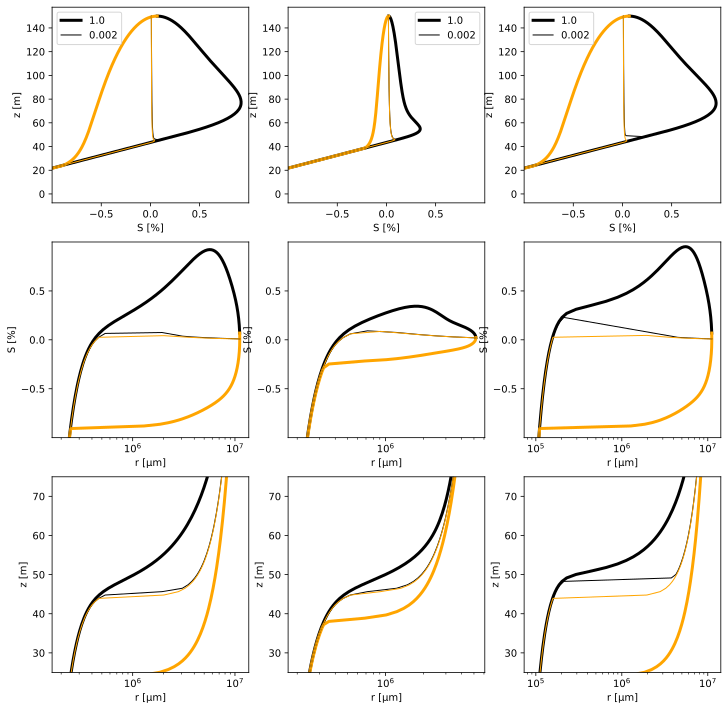

In [4]:
figsize = (12, 12)
fig, axs = plt.subplots(3, 3, figsize=figsize)

linewidths = {
    100 * si.centimetre / si.second: 3,
    50 * si.centimetre / si.second: 2,
    .2 * si.centimetre / si.second: 1
}

r_label = "r [μm]"
r_unit = si.micrometre

S_ticks = (-0.5, 0, 0.5)
S_label = "S [%]"
S_unit = 0.01

z_label = "z [m]"
z_unit = si.metre

for idx, output_item in enumerate(output):
    linewidth = linewidths[setups[idx].w_avg]
    
    if setups[idx].N_STP == 50 / si.centimetre**3 and setups[idx].r_dry == 0.1 * si.micrometre:
        col_idx = 0
    elif setups[idx].N_STP == 500 / si.centimetre**3 and setups[idx].r_dry == 0.1 * si.micrometre:
        col_idx = 1
    elif setups[idx].N_STP == 50 / si.centimetre**3 and setups[idx].r_dry == 0.05 * si.micrometre:
        col_idx = 2
    else:
        assert False
        
    split = lambda arg1, arg2: (arg1[0:np.argmax(arg2) + 1], arg1[np.argmax(arg2):-1])

    z = in_unit(np.asarray(output_item["z"]), z_unit)
    r = in_unit(np.asarray(output_item["r"]), r_unit)
    S = in_unit(np.asarray(output_item["RH"])-1, S_unit)

    z1, z2 = split(z, z)
    S1, S2 = split(S, z)
    r1, r2 = split(r, z)

    axs[0][col_idx].plot(S1, z1, color='black', linewidth=linewidth, label=setups[idx].w_avg)
    axs[0][col_idx].plot(S2, z2, color='orange', linewidth=linewidth)
    axs[0][col_idx].grid()
    axs[0][col_idx].set_xlim([-1, 1])
    axs[0][col_idx].legend()
    axs[0][col_idx].set_xticks(S_ticks)
    axs[0][col_idx].set_xlabel(S_label)
    axs[0][col_idx].set_ylabel(z_label)

    axs[1][col_idx].plot(r1, S1, color='black', linewidth=linewidth)
    axs[1][col_idx].plot(r2, S2, color='orange', linewidth=linewidth)
    axs[1][col_idx].grid()
    axs[1][col_idx].set_ylim([-1, 1])
    axs[1][col_idx].set_xscale('log')
    axs[1][col_idx].set_yticks(S_ticks)
    axs[1][col_idx].set_xlabel(r_label)
    axs[1][col_idx].set_ylabel(S_label)

    axs[2][col_idx].plot(r1, z1, color='black', linewidth=linewidth)
    axs[2][col_idx].plot(r2, z2, color='orange', linewidth=linewidth)
    axs[2][col_idx].grid()
    axs[2][col_idx].set_ylim([25, 75])
    axs[2][col_idx].set_xscale('log')
    axs[2][col_idx].set_xlabel(r_label)
    axs[2][col_idx].set_ylabel(z_label)

show_plot('fig_5.pdf')